# SOFI-style Segmentation from Hand Keypoints

Reproduces (an approximation of) the "Segmentation based on Optical Flow Intensity" (SOFI) idea from *Decoding the Speaking Hands*, using frame-to-frame **hand-keypoint displacement** as a proxy for optical flow, computed directly from `hand_keypoints_features.csv` (no video decoding needed).

**Caveats to keep in mind:**
- This is keypoint displacement, not real Farneback optical flow on pixels — same idea, cheaper, but not numerically identical.
- Fixed-threshold segmentation (Algorithm 1) is known to be brittle across different words — see the sweep at the bottom. This motivates implementing Algorithm 2 (dynamic, local-minima-based) next.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Set the path to your CSV here (edit this for your machine):

In [ ]:
CSV_PATH = "hand_keypoints_features.csv"  

df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()


(72087, 76)


,signer_id,video_id,frame_id,hand_detected,bbox_x,bbox_y,bbox_w,bbox_h,kp0_x,kp0_y,...,d_ring_pip_to_palm,d_ring_dip_to_palm,d_ring_tip_to_palm,d_pinky_pip_to_palm,d_pinky_dip_to_palm,d_pinky_tip_to_palm,d_thumb_index_tip,d_thumb_index_pip,d_thumb_middle_pip,d_thumb_to_palm
0,signer1-F,ولید.MP4,0,1,0.601276,0.886261,0.050781,0.128969,0.642128,0.886261,...,2.439706,2.923609,3.109384,1.911211,2.476471,2.710665,1.185565,1.353241,1.741135,2.717882
1,signer1-F,ولید.MP4,1,1,0.600954,0.885571,0.051609,0.131972,0.641428,0.885571,...,2.262334,2.756546,2.981518,1.720823,2.268007,2.530819,1.348507,1.272009,1.634495,2.605060
2,signer1-F,ولید.MP4,2,1,0.601151,0.885463,0.051432,0.131225,0.641473,0.885463,...,2.199240,2.690733,2.916102,1.655458,2.194674,2.450884,1.291097,1.240212,1.618192,2.551425
3,signer1-F,ولید.MP4,3,1,0.601409,0.885891,0.050770,0.128610,0.641071,0.885891,...,2.262105,2.748254,2.953865,1.702789,2.243079,2.485276,1.173906,1.262162,1.641742,2.563848
4,signer1-F,ولید.MP4,4,1,0.601336,0.885620,0.051072,0.129803,0.640893,0.885620,...,2.212734,2.710910,2.934609,1.676895,2.214729,2.465920,1.236189,1.239267,1.591268,2.553317


## Core functions

In [3]:
KP_COLS_X = [f"kp{i}_x" for i in range(21)]
KP_COLS_Y = [f"kp{i}_y" for i in range(21)]


def motion_intensity(df_video: pd.DataFrame) -> np.ndarray:
    """Per-frame motion intensity = mean displacement of all 21 keypoints
    vs. the previous frame. First frame gets 0."""
    xs = df_video[KP_COLS_X].to_numpy()
    ys = df_video[KP_COLS_Y].to_numpy()
    dx = np.diff(xs, axis=0)
    dy = np.diff(ys, axis=0)
    disp = np.sqrt(dx**2 + dy**2).mean(axis=1)  # mean over 21 keypoints
    return np.concatenate([[0.0], disp])


In [4]:
def smooth_running_avg(x: np.ndarray, window: int = 10) -> np.ndarray:
    """Running average, matching the paper's smoothing of OFI over 10 frames."""
    return pd.Series(x).rolling(window=window, min_periods=1, center=False).mean().to_numpy()


In [5]:
def segment_fixed_threshold(ofi: np.ndarray, threshold: float, min_len: int = 9):
    """Algorithm 1 from the paper: group consecutive low-motion frames into
    segments; keep only segments longer than min_len frames."""
    segments = []
    start = None
    for i, val in enumerate(ofi):
        if val <= threshold:
            if start is None:
                start = i
        else:
            if start is not None and (i - start) > min_len:
                segments.append((start, i - 1))
            start = None
    if start is not None and (len(ofi) - start) > min_len:
        segments.append((start, len(ofi) - 1))
    return segments


In [6]:
def process_video(df: pd.DataFrame, signer_id: str, video_id: str, threshold: float):
    sub = df[(df.signer_id == signer_id) & (df.video_id == video_id)].sort_values("frame_id").reset_index(drop=True)
    if sub["hand_detected"].mean() < 0.5:
        return sub, None, None, []  # skip badly-detected videos for now
    raw_ofi = motion_intensity(sub)
    smooth_ofi = smooth_running_avg(raw_ofi, window=10)
    segments = segment_fixed_threshold(smooth_ofi, threshold=threshold)
    return sub, raw_ofi, smooth_ofi, segments


## Try it on one video

In [7]:
SIGNER = "signer1-F"
VIDEO = "ولید.MP4"
THRESHOLDS = [0.0005, 0.0007, 0.0008, 0.0009, 0.001]

for thr in THRESHOLDS:
    sub, raw, smooth, segs = process_video(df, SIGNER, VIDEO, threshold=thr)
    if segs is None:
        print(f"threshold={thr:<8} -> skipped (hand_detected rate below 50%)")
        continue
    lengths = [b - a + 1 for a, b in segs]
    print(f"threshold={thr:<8} -> {len(segs)} segments, lengths={lengths}")


threshold=0.0005   -> 0 segments, lengths=[]
threshold=0.0007   -> 1 segments, lengths=[15]
threshold=0.0008   -> 5 segments, lengths=[14, 11, 13, 13, 22]
threshold=0.0009   -> 6 segments, lengths=[35, 13, 24, 12, 20, 39]
threshold=0.001    -> 5 segments, lengths=[37, 27, 49, 27, 41]


## Visualize the motion-intensity signal and segment boundaries

Pick one threshold and plot it — useful for eyeballing whether segment boundaries line up with what you'd expect from the video.

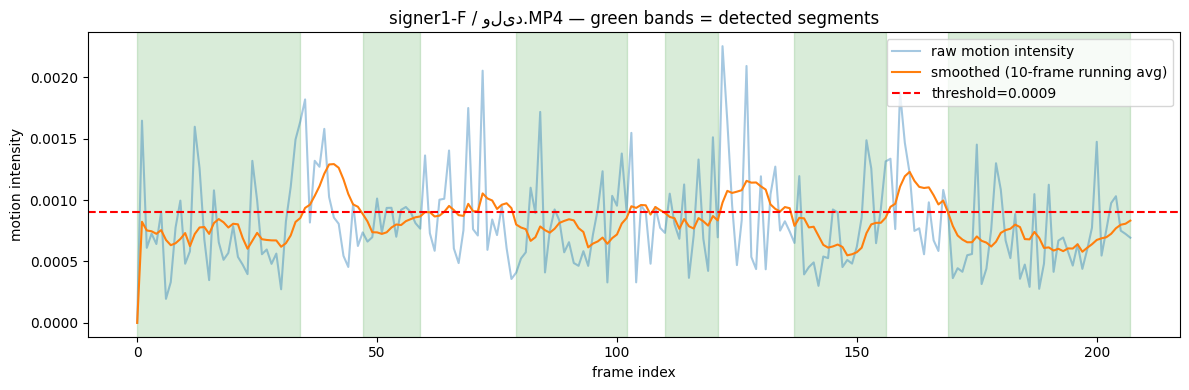

In [8]:
thr_to_plot = 0.0009
sub, raw, smooth, segs = process_video(df, SIGNER, VIDEO, threshold=thr_to_plot)

plt.figure(figsize=(12, 4))
plt.plot(raw, alpha=0.4, label="raw motion intensity")
plt.plot(smooth, label="smoothed (10-frame running avg)")
plt.axhline(thr_to_plot, color="red", linestyle="--", label=f"threshold={thr_to_plot}")

for a, b in segs:
    plt.axvspan(a, b, color="green", alpha=0.15)

plt.xlabel("frame index")
plt.ylabel("motion intensity")
plt.title(f"{SIGNER} / {VIDEO} — green bands = detected segments")
plt.legend()
plt.tight_layout()
plt.show()


## What this shows

Segment count and boundaries shift a lot depending on the threshold, and don't cleanly match the letter count of the word — this is the same brittleness the original paper found with a fixed-threshold approach (Algorithm 1), which is why they moved to a dynamic, local-minima-based method (Algorithm 2) instead.

**Next step:** implement Algorithm 2 on top of `motion_intensity()` — track local minima in the motion signal directly instead of using one global cutoff, so the segmentation can adapt per word instead of needing a hand-tuned threshold.
